In [1]:
import numpy as np
import pandas as pd

In [2]:
zero_day_attack = ["backdoor","mitm","ransomware"]

In [3]:
file_path = r"data\NF_ToN_IoT.csv"

In [23]:
chunks = pd.read_csv(
    file_path,
    chunksize=200000,
    low_memory=False
)

train_chunks = []
zero_day_chunks = []
seen_attack_chunks = []
benign_chunks = []

for chunk in chunks:

    chunk["Attack"] = chunk["Attack"].str.lower()

    # zero-day attacks
    zd = chunk[chunk["Attack"].isin(zero_day_attack)]

    # seen attacks
    seen = chunk[(~chunk["Attack"].isin(zero_day_attack)) &
                 (chunk["Label"] == 1)]

    # benign traffic
    benign = chunk[chunk["Label"] == 0]

    # training data (exclude zero-day)
    train_part = chunk[~chunk["Attack"].isin(zero_day_attack)]

    zero_day_chunks.append(zd)

    seen_attack_chunks.append(
        seen.sample(frac=0.01, random_state=42)
    )

    benign_chunks.append(
        benign.sample(frac=0.01, random_state=42)
    )

    train_chunks.append(
        train_part.sample(frac=0.02, random_state=42)
    )

In [24]:
train_df = pd.concat(train_chunks, ignore_index=True)

zero_day_df = pd.concat(zero_day_chunks, ignore_index=True)
seen_attack_df = pd.concat(seen_attack_chunks, ignore_index=True)
benign_df = pd.concat(benign_chunks, ignore_index=True)

test_df = pd.concat(
    [zero_day_df, seen_attack_df, benign_df],
    ignore_index=True
)

test_df = test_df.sample(frac=1, random_state=42)

train_df.shape, test_df.shape

((262170, 43), (158425, 43))

In [25]:
train_df["Label"].value_counts()

Label
1    190257
0     71913
Name: count, dtype: int64

In [27]:
train_df["Attack"].value_counts()

Attack
benign       71913
scanning     60133
xss          49074
ddos         34822
password     19990
injection    13171
dos          13067
Name: count, dtype: int64

In [29]:
train_df.memory_usage(deep=True).sum() / 1024**2

np.float64(87.4863691329956)

In [31]:
def reduce_memory(df):

    for col in df.columns:

        if df[col].dtype == "float64":
            df[col] = df[col].astype("float32")

        elif df[col].dtype == "int64":
            df[col] = df[col].astype("int32")

    return df


train_df = reduce_memory(train_df)
test_df = reduce_memory(test_df)

c:\Users\abhit\OneDrive\Desktop\pw\venv\Lib\site-packages\pandas\core\dtypes\astype.py:136: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=copy)
c:\Users\abhit\OneDrive\Desktop\pw\venv\Lib\site-packages\pandas\core\dtypes\astype.py:136: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=copy)
c:\Users\abhit\OneDrive\Desktop\pw\venv\Lib\site-packages\pandas\core\dtypes\astype.py:136: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=copy)
c:\Users\abhit\OneDrive\Desktop\pw\venv\Lib\site-packages\pandas\core\dtypes\astype.py:136: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=copy)


In [32]:
train_df.memory_usage(deep=True).sum() / 1024**2

np.float64(45.48220348358154)

In [33]:
train_df.columns

Index(['L4_SRC_PORT', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO', 'IN_BYTES',
       'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS', 'TCP_FLAGS', 'CLIENT_TCP_FLAGS',
       'SERVER_TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS', 'DURATION_IN',
       'DURATION_OUT', 'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT',
       'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN',
       'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES',
       'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS',
       'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS',
       'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT',
       'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES',
       'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES',
       'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT',
       'ICMP_TYPE', 'ICMP_IPV4_TYPE', 'DNS_QUERY_ID', 'DNS_QUERY_TYPE',
       'DNS_TTL_ANSWER', 'FTP_COMMAND_RET_CODE', 'Label', 'Attack'],
      dtype='str')

In [34]:
remove_features = [
    "DNS_QUERY_ID",
    "DNS_QUERY_TYPE",
    "DNS_TTL_ANSWER",
    "FTP_COMMAND_RET_CODE",
    "ICMP_IPV4_TYPE"
]

train_df.drop(columns=remove_features,
                inplace=True,
                errors="ignore")

test_df.drop(columns=remove_features,
                   inplace=True,
                   errors="ignore")

In [35]:
train_df.shape, test_df.shape

((262170, 38), (158425, 38))

In [36]:
numeric_cols = train_df.select_dtypes(
    include=[np.number]
).columns

In [37]:
print(
    np.isinf(train_df[numeric_cols]).sum().sum()
)

3


In [38]:
train_df[numeric_cols] = train_df[
    numeric_cols
].replace([np.inf, -np.inf], np.nan)

test_df[numeric_cols] = test_df[
    numeric_cols
].replace([np.inf, -np.inf], np.nan)

In [39]:
median_vals = train_df[numeric_cols].median()

train_df[numeric_cols] = train_df[
    numeric_cols
].fillna(median_vals)

test_df[numeric_cols] = test_df[
    numeric_cols
].fillna(median_vals)

In [40]:
print(
    np.isinf(train_df[numeric_cols]).sum().sum()
)

print(
    train_df[numeric_cols].isna().sum().sum()
)

0
0


In [41]:
skewed_features = train_df.drop(
    ["Label","Attack"], axis=1
).skew()

log_cols = skewed_features[
    skewed_features > 1
].index

print("Log transforming:", list(log_cols))

Log transforming: ['L4_DST_PORT', 'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS', 'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT', 'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT', 'MAX_IP_PKT_LEN', 'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES', 'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS', 'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS', 'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT', 'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES', 'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES', 'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX_OUT', 'ICMP_TYPE']


In [42]:
for col in log_cols:
    train_df[col] = np.log1p(train_df[col])
    test_df[col] = np.log1p(test_df[col])

c:\Users\abhit\OneDrive\Desktop\pw\venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [46]:
train_df.max(), test_df.max()

(L4_SRC_PORT                        65535
 L4_DST_PORT                     11.09034
 PROTOCOL                        4.077537
 L7_PROTO                        5.517453
 IN_BYTES                       16.199967
 IN_PKTS                        11.231438
 OUT_BYTES                      16.127713
 OUT_PKTS                       11.200472
 TCP_FLAGS                            223
 CLIENT_TCP_FLAGS                     223
 SERVER_TCP_FLAGS                     152
 FLOW_DURATION_MILLISECONDS     15.272954
 DURATION_IN                    11.664169
 DURATION_OUT                   11.664169
 MIN_TTL                              255
 MAX_TTL                              255
 LONGEST_FLOW_PKT                9.558671
 SHORTEST_FLOW_PKT               7.313887
 MIN_IP_PKT_LEN                       169
 MAX_IP_PKT_LEN                  9.558671
 SRC_TO_DST_SECOND_BYTES        37.644691
 DST_TO_SRC_SECOND_BYTES        78.566902
 RETRANSMITTED_IN_BYTES         12.508992
 RETRANSMITTED_IN_PKTS           6

In [43]:
X_train = train_df.drop(
    columns=["Label", "Attack"]
)

y_train = train_df["Label"]

X_test = test_df.drop(
    columns=["Label", "Attack"]
)

y_test = test_df["Label"]

print(X_train.shape, X_test.shape)

(262170, 36) (158425, 36)


In [44]:
constant_cols = X_train.columns[
    X_train.nunique() <= 1
]

X_train.drop(columns=constant_cols, inplace=True)
X_test.drop(columns=constant_cols, inplace=True)

In [45]:
from sklearn.preprocessing import StandardScaler

In [47]:
scaler = StandardScaler()

In [48]:
X_train.max()

L4_SRC_PORT                    65535.000000
L4_DST_PORT                       11.090340
PROTOCOL                           4.077537
L7_PROTO                           5.517453
IN_BYTES                          16.199967
IN_PKTS                           11.231438
OUT_BYTES                         16.127713
OUT_PKTS                          11.200472
TCP_FLAGS                        223.000000
CLIENT_TCP_FLAGS                 223.000000
SERVER_TCP_FLAGS                 152.000000
FLOW_DURATION_MILLISECONDS        15.272954
DURATION_IN                       11.664169
DURATION_OUT                      11.664169
MIN_TTL                          255.000000
MAX_TTL                          255.000000
LONGEST_FLOW_PKT                   9.558671
SHORTEST_FLOW_PKT                  7.313887
MIN_IP_PKT_LEN                   169.000000
MAX_IP_PKT_LEN                     9.558671
SRC_TO_DST_SECOND_BYTES           37.644691
DST_TO_SRC_SECOND_BYTES           78.566902
RETRANSMITTED_IN_BYTES          

In [49]:
X_test.max()

L4_SRC_PORT                    65535.000000
L4_DST_PORT                       11.090355
PROTOCOL                           4.077537
L7_PROTO                           5.505332
IN_BYTES                          14.815958
IN_PKTS                           10.564189
OUT_BYTES                         16.901855
OUT_PKTS                          11.611974
TCP_FLAGS                        223.000000
CLIENT_TCP_FLAGS                 223.000000
SERVER_TCP_FLAGS                 223.000000
FLOW_DURATION_MILLISECONDS        15.272954
DURATION_IN                       11.132163
DURATION_OUT                      11.038753
MIN_TTL                          255.000000
MAX_TTL                          255.000000
LONGEST_FLOW_PKT                  10.752805
SHORTEST_FLOW_PKT                  7.313887
MIN_IP_PKT_LEN                   172.000000
MAX_IP_PKT_LEN                    10.752805
SRC_TO_DST_SECOND_BYTES           88.710228
DST_TO_SRC_SECOND_BYTES           88.222969
RETRANSMITTED_IN_BYTES          

In [50]:
X_train.isna().sum().sum(), X_test.isna().sum().sum()

(np.int64(4), np.int64(55))

In [51]:
X_train.isna().sum()[X_train.isna().sum() > 0]

DST_TO_SRC_AVG_THROUGHPUT    4
dtype: int64

In [52]:
X_test.isna().sum()[X_test.isna().sum() > 0]

SRC_TO_DST_AVG_THROUGHPUT     6
DST_TO_SRC_AVG_THROUGHPUT    49
dtype: int64

In [53]:
median_vals = X_train.median()

In [54]:
X_train = X_train.fillna(median_vals)
X_test = X_test.fillna(median_vals)

In [55]:
X_train.isna().sum().sum(), X_test.isna().sum().sum()

(np.int64(0), np.int64(0))

In [56]:
from sklearn.utils import resample

In [57]:
Xy_train = pd.concat(
    [X_train, y_train],
    axis=1
)

majority = Xy_train[Xy_train["Label"] == 1]
minority = Xy_train[Xy_train["Label"] == 0]

majority_small = resample(
    majority,
    replace=False,
    n_samples=60000,
    random_state=42
)

train_small = pd.concat(
    [majority_small, minority]
)

In [58]:
X_small = train_small.drop("Label", axis=1)
y_small = train_small["Label"]

In [59]:
X_train_scaled = scaler.fit_transform(X_small)

X_test_scaled = scaler.transform(X_test)

In [60]:
X_small.shape

(131913, 36)

In [61]:
y_small.value_counts()

Label
0    71913
1    60000
Name: count, dtype: int64

In [62]:
np.isnan(X_train_scaled).sum(), np.isnan(X_test_scaled).sum()

(np.int64(0), np.int64(0))

In [63]:
from imblearn.over_sampling import KMeansSMOTE

In [64]:
from imblearn.over_sampling import KMeansSMOTE

smote = KMeansSMOTE(
    sampling_strategy="auto",   # VERY IMPORTANT
    k_neighbors=3,
    random_state=42,
    cluster_balance_threshold=0.1
)

X_train_bal, y_train_bal = smote.fit_resample(
    X_train_scaled,
    y_small
)

In [65]:
y_train_bal.value_counts()

Label
1    71920
0    71913
Name: count, dtype: int64

In [83]:
from sklearn.model_selection import train_test_split

X_demo, _, y_demo, _ = train_test_split(
    X_train_bal,
    y_train_bal,
    train_size=4000,
    stratify=y_train_bal,
    random_state=42
)

In [88]:
y_demo = np.array(y_demo)

In [89]:
print(type(X_demo))
print(type(y_demo))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [78]:
X_demo.shape, y_demo.shape

((4000, 36), (4000,))

In [90]:
unique, counts = np.unique(y_demo, return_counts=True)
print(dict(zip(unique, counts)))

{np.int32(0): np.int64(2000), np.int32(1): np.int64(2000)}


In [66]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Reshape

In [91]:
def build_q_network(state_size, action_size):

    model = Sequential()

    model.add(Dense(64, activation='relu',
                    input_shape=(state_size,)))
    model.add(Dropout(0.1))

    model.add(Reshape((1, 64)))

    model.add(LSTM(64, return_sequences=True))
    model.add(LSTM(64, return_sequences=True))
    model.add(LSTM(64))

    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.1))

    model.add(Dense(action_size, activation='linear'))

    model.compile(
        optimizer='adam',
        loss='mse'
    )

    return model

In [92]:
class NIDSEnvironment:

    def __init__(self, X, y):
        self.X = X
        self.y = y
        self.index = 0
        self.size = len(X)

    def reset(self):
        self.index = 0
        return self.X[self.index]

    def step(self, action):

        true_label = self.y[self.index]

        reward = 1 if action == true_label else -1

        self.index += 1
        done = self.index >= self.size

        next_state = None if done else self.X[self.index]

        return next_state, reward, done

In [95]:
import random
from collections import deque
import numpy as np

class DQNAgent:

    def __init__(self, state_size, action_size):

        self.state_size = state_size
        self.action_size = action_size

        self.gamma = 0.97
        self.epsilon = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.996

        self.memory = deque(maxlen=2000)

        self.model = build_q_network(state_size, action_size)

    def act(self, state):

        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)

        q_values = self.model.predict(
            state.reshape(1, -1),
            verbose=0
        )

        return np.argmax(q_values[0])

    def remember(self, state, action, reward, next_state, done):
        self.memory.append(
            (state, action, reward, next_state, done)
        )

    def replay(self, batch_size):
        minibatch = random.sample(self.memory, batch_size)
        states = np.array([x[0] for x in minibatch])
        actions = np.array([x[1] for x in minibatch])
        rewards = np.array([x[2] for x in minibatch])
        next_states = np.array([x[3] for x in minibatch])
        dones = np.array([x[4] for x in minibatch])
        # current Q values
        target = self.model.predict(states, verbose=0)
        # next state Q values
        target_next = self.model.predict(next_states, verbose=0)
        for i in range(batch_size):
            if dones[i]:
                target[i][actions[i]] = rewards[i]
            else:
                target[i][actions[i]] = rewards[i] + self.gamma * np.max(target_next[i])
                
        # train once on full batch
        self.model.fit(states, target, epochs=1, verbose=0)
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

In [97]:
env = NIDSEnvironment(X_demo, y_demo)

state_size = X_train_bal.shape[1]
action_size = 2

agent = DQNAgent(state_size, action_size)

episodes = 5
batch_size = 32
max_steps = 1500

for e in range(episodes):

    state = env.reset()
    done = False
    step = 0

    while not done and step < max_steps:

        action = agent.act(state)

        next_state, reward, done = env.step(action)

        agent.remember(state, action, reward, next_state, done)

        state = next_state
        step += 1

        if len(agent.memory) > batch_size and step % 10 == 0:
            agent.replay(batch_size)

    print("Episode:", e, "Epsilon:", agent.epsilon)

Episode: 0 Epsilon: 0.5547824936194926
Episode: 1 Epsilon: 0.30410496575932205
Episode: 2 Epsilon: 0.16669565327507846
Episode: 3 Epsilon: 0.09137450535022515
Episode: 4 Epsilon: 0.0500870902387625


In [98]:
preds = []

for state in X_test_scaled[:2000]:

    q = agent.model.predict(state.reshape(1,-1), verbose=0)

    action = np.argmax(q[0])

    preds.append(action)

In [99]:
from sklearn.metrics import classification_report

In [100]:
print(classification_report(y_test[:2000], preds))

              precision    recall  f1-score   support

           0       0.49      0.93      0.64       454
           1       0.97      0.72      0.83      1546

    accuracy                           0.77      2000
   macro avg       0.73      0.82      0.74      2000
weighted avg       0.86      0.77      0.78      2000



In [101]:
from sklearn.metrics import accuracy_score

In [102]:
accuracy_score(y_test[:2000], preds)

0.7665

In [103]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


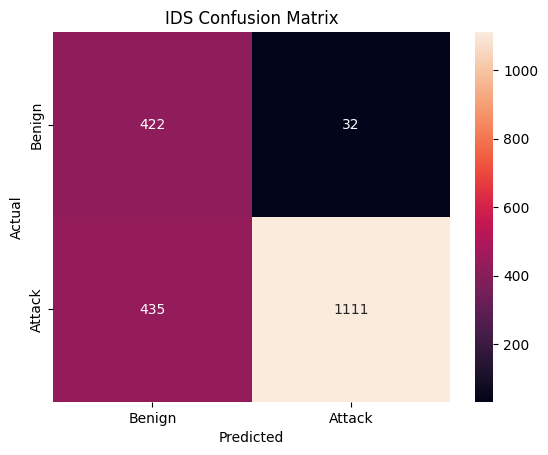

In [104]:
cm = confusion_matrix(y_test[:2000], preds)

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Benign","Attack"],
            yticklabels=["Benign","Attack"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("IDS Confusion Matrix")
plt.show()

In [118]:
remove_features = remove_features.extend(["Label", "Attack"])

In [121]:
x_zero = zero_day_chunks[0].drop(columns=["Label", "Attack", "DNS_QUERY_ID",
    "DNS_QUERY_TYPE",
    "DNS_TTL_ANSWER",
    "FTP_COMMAND_RET_CODE",
    "ICMP_IPV4_TYPE"]).values
y_zero = zero_day_chunks[0]["Label"].values


In [122]:
x_zero = pd.DataFrame(x_zero, columns=X_train.columns)

In [123]:
X_zero_scaled = scaler.transform(x_zero)

In [124]:
zero_preds = []

for state in X_zero_scaled:

    q_values = agent.model.predict(
        state.reshape(1,-1),
        verbose=0
    )

    zero_preds.append(np.argmax(q_values[0]))

In [126]:
print(classification_report(y_zero, zero_preds))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.07      0.14        40

    accuracy                           0.07        40
   macro avg       0.50      0.04      0.07        40
weighted avg       1.00      0.07      0.14        40



c:\Users\abhit\OneDrive\Desktop\pw\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\abhit\OneDrive\Desktop\pw\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\abhit\OneDrive\Desktop\pw\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [127]:
confusion_matrix(y_zero, zero_preds)

array([[ 0,  0],
       [37,  3]])